# Crop Recommendation classification
Trains crop suitability classifiers with the correct evaluation methodology:
1. Split data into train (80%) and test (20%) **first**
2. Apply 5-fold CV **only on the train set** for model comparison
3. Report per-fold CV scores for transparency
4. Evaluate best model **once** on the held-out test set for the final unbiased estimate

## Imports & paths

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings, os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42)

CROP_PATH = 'crop_clean.csv'
SOIL_PATH = 'soil_zoned.csv'
OUT_DIR   = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

## Load data & define features

In [3]:
crop = pd.read_csv(CROP_PATH)
soil = pd.read_csv(SOIL_PATH)

# Features present in both datasets
FEATURES = [
    'nitrogen_total', 'phosphorus_avail', 'potassium_exch',
    'pH_water', 'rainfall_annual',
    'NPK_total', 'N_to_P', 'N_to_K', 'P_to_K'
]

le = LabelEncoder()
le.fit(crop['label'])

scaler = StandardScaler()
X = scaler.fit_transform(crop[FEATURES].values)
y = crop['crop_encoded'].values

print(f'Crop dataset  : {X.shape[0]} rows x {X.shape[1]} features')
print(f'Crop classes  : {len(le.classes_)} : {list(le.classes_)}')

Crop dataset  : 2200 rows x 9 features
Crop classes  : 22 : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


## Train / test split
Stratified to preserve class balance in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set : {len(X_train)} samples (80%)')
print(f'Test set  : {len(X_test)} samples (20%)  <- locked until final evaluation')
print(f'Samples per class in train: {len(X_train) // len(le.classes_)}')

Train set : 1760 samples (80%)
Test set  : 440 samples (20%)  <- locked until final evaluation
Samples per class in train: 80


## Exploratory analysis

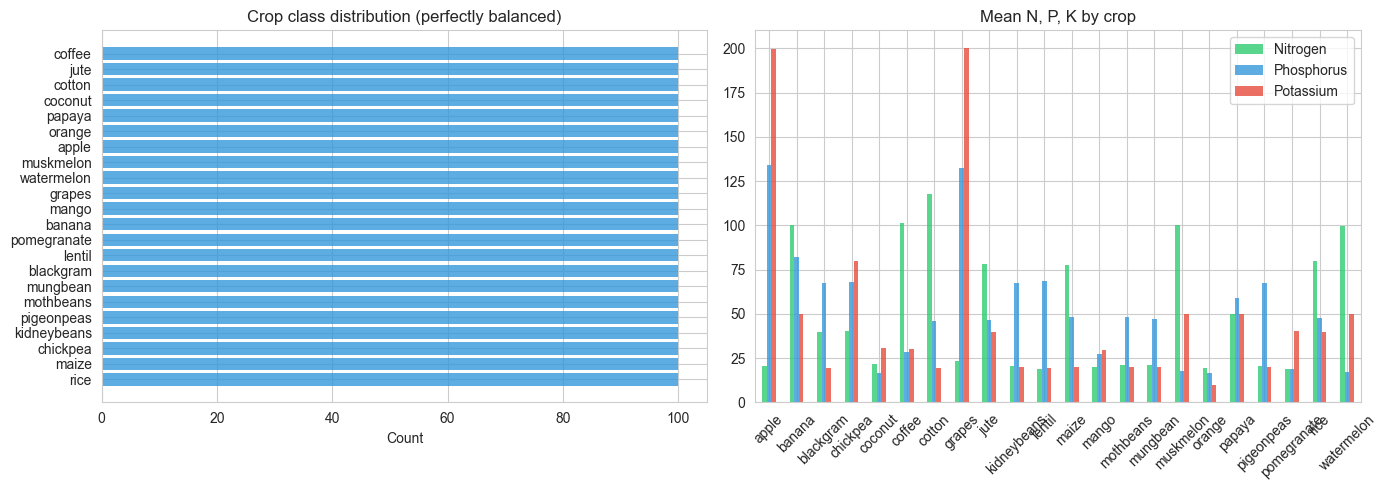

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = crop['label'].value_counts()
axes[0].barh(class_counts.index, class_counts.values, color='#3498db', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Count')
axes[0].set_title('Crop class distribution (perfectly balanced)')

npk_means = crop.groupby('label')[['nitrogen_total','phosphorus_avail','potassium_exch']].mean()
npk_means.plot(kind='bar', ax=axes[1], color=['#2ecc71','#3498db','#e74c3c'], edgecolor='none', alpha=0.8)
axes[1].set_title('Mean N, P, K by crop')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Nitrogen','Phosphorus','Potassium'])

plt.tight_layout()
plt.show()

## Define all 13 classifiers

In [6]:
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=7),
    'SVC'                : SVC(kernel='rbf', C=10, random_state=42, probability=True),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Bagging'            : BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees'        : ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost'           : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boost'     : GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM'           : LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost'           : CatBoostClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbose=0),
    'ANN (MLP)'          : MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu',
                                          max_iter=500, random_state=42, early_stopping=True),
}
print(f'{len(MODELS)} classifiers defined.')

13 classifiers defined.


## 5-fold CV on train set per-fold results

In [7]:
kf           = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary   = []
fold_records = []

for name, model in MODELS.items():
    cv = cross_validate(
        model, X_train, y_train, cv=kf,
        scoring={'accuracy':'accuracy', 'f1_macro':'f1_macro', 'f1_weighted':'f1_weighted'},
        return_train_score=True
    )
    for i in range(5):
        fold_records.append({
            'Model'       : name,
            'Fold'        : i + 1,
            'Val_Accuracy': round(cv['test_accuracy'][i], 4),
            'Val_F1_macro': round(cv['test_f1_macro'][i], 4),
            'Train_Acc'   : round(cv['train_accuracy'][i], 4),
        })
    cv_summary.append({
        'Model'      : name,
        'CV_Acc'     : round(cv['test_accuracy'].mean(), 4),
        'CV_Acc_std' : round(cv['test_accuracy'].std(), 4),
        'CV_F1_macro': round(cv['test_f1_macro'].mean(), 4),
        'CV_F1_weighted': round(cv['test_f1_weighted'].mean(), 4),
        'Train_Acc'  : round(cv['train_accuracy'].mean(), 4),
        'Overfit'    : round(cv['train_accuracy'].mean() - cv['test_accuracy'].mean(), 4),
    })
    print(f"  {name:<22} CV_Acc={cv_summary[-1]['CV_Acc']:.4f} +/- {cv_summary[-1]['CV_Acc_std']:.4f}  "
          f"F1={cv_summary[-1]['CV_F1_macro']:.4f}  overfit={cv_summary[-1]['Overfit']:.4f}")

cv_df   = pd.DataFrame(cv_summary).sort_values('CV_Acc', ascending=False).reset_index(drop=True)
fold_df = pd.DataFrame(fold_records)

  Logistic Regression    CV_Acc=0.8648 +/- 0.0157  F1=0.8625  overfit=0.0159
  KNN                    CV_Acc=0.8966 +/- 0.0146  F1=0.8944  overfit=0.0386
  SVC                    CV_Acc=0.9455 +/- 0.0125  F1=0.9444  overfit=0.0175
  Decision Tree          CV_Acc=0.8608 +/- 0.0552  F1=0.8445  overfit=0.0212
  Bagging                CV_Acc=0.9619 +/- 0.0087  F1=0.9613  overfit=0.0381
  Random Forest          CV_Acc=0.9676 +/- 0.0053  F1=0.9667  overfit=0.0324
  Extra Trees            CV_Acc=0.9477 +/- 0.0109  F1=0.9471  overfit=0.0523
  AdaBoost               CV_Acc=0.2500 +/- 0.0590  F1=0.1568  overfit=0.0065
  Gradient Boost         CV_Acc=0.9545 +/- 0.0074  F1=0.9548  overfit=0.0455
  XGBoost                CV_Acc=0.9528 +/- 0.0112  F1=0.9529  overfit=0.0472
  LightGBM               CV_Acc=0.9585 +/- 0.0085  F1=0.9581  overfit=0.0415
  CatBoost               CV_Acc=0.9682 +/- 0.0118  F1=0.9673  overfit=0.0163
  ANN (MLP)              CV_Acc=0.9125 +/- 0.0208  F1=0.9110  overfit=0.0178

## Per-fold results table

In [8]:
fold_pivot = fold_df.pivot(index='Model', columns='Fold', values='Val_Accuracy')
fold_pivot.columns = [f'Fold {i}' for i in fold_pivot.columns]
fold_pivot['Mean'] = fold_pivot.mean(axis=1).round(4)
fold_pivot['Std']  = fold_pivot.std(axis=1).round(4)
fold_pivot = fold_pivot.sort_values('Mean', ascending=False)

print('Per-fold validation Accuracy (CV on train set only):')
print(fold_pivot.round(4).to_string())

Per-fold validation Accuracy (CV on train set only):
                     Fold 1  Fold 2  Fold 3  Fold 4  Fold 5    Mean     Std
Model                                                                      
CatBoost             0.9489  0.9801  0.9602  0.9773  0.9744  0.9682  0.0118
Random Forest        0.9602  0.9744  0.9688  0.9716  0.9631  0.9676  0.0053
Bagging              0.9489  0.9688  0.9545  0.9716  0.9659  0.9619  0.0087
LightGBM             0.9574  0.9688  0.9432  0.9631  0.9602  0.9585  0.0085
Gradient Boost       0.9403  0.9602  0.9545  0.9574  0.9602  0.9545  0.0074
XGBoost              0.9432  0.9716  0.9403  0.9517  0.9574  0.9528  0.0112
Extra Trees          0.9403  0.9631  0.9318  0.9545  0.9489  0.9477  0.0109
SVC                  0.9347  0.9631  0.9290  0.9545  0.9460  0.9455  0.0125
ANN (MLP)            0.8722  0.9261  0.9148  0.9205  0.9290  0.9125  0.0207
KNN                  0.8835  0.9205  0.8835  0.9062  0.8892  0.8966  0.0146
Logistic Regression  0.8523  0.8892

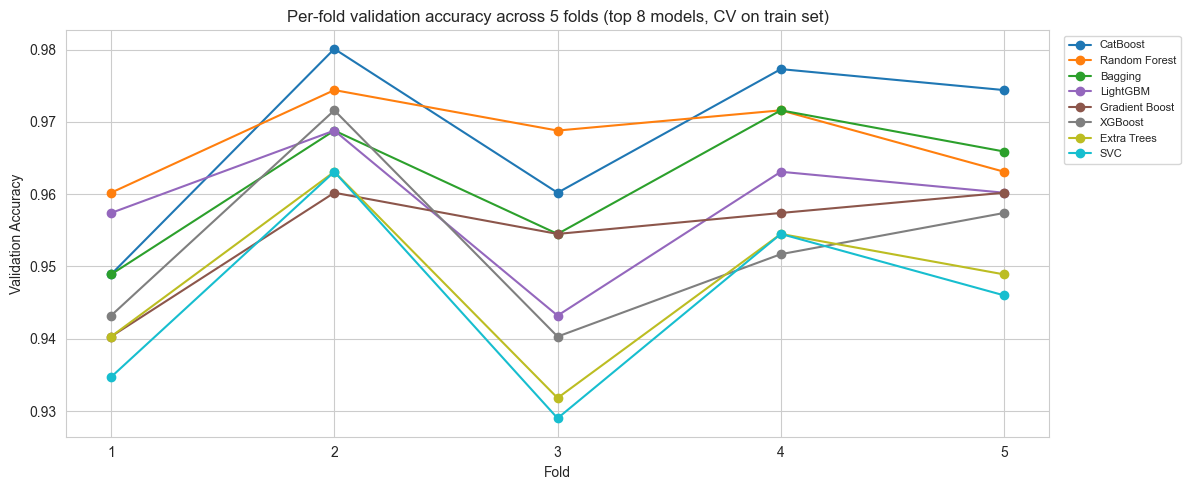

In [9]:
top_models = cv_df['Model'].head(8).tolist()
fold_top   = fold_df[fold_df['Model'].isin(top_models)]

fig, ax = plt.subplots(figsize=(12, 5))
colors_map = plt.cm.tab10(np.linspace(0, 1, len(top_models)))

for color, name in zip(colors_map, top_models):
    sub = fold_top[fold_top['Model'] == name]
    ax.plot(sub['Fold'], sub['Val_Accuracy'], marker='o', label=name, color=color, linewidth=1.5)

ax.set_xlabel('Fold')
ax.set_ylabel('Validation Accuracy')
ax.set_xticks([1,2,3,4,5])
ax.set_title('Per-fold validation accuracy across 5 folds (top 8 models, CV on train set)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## CV summary & visual comparison

In [10]:
print('CV summary (sorted by CV Accuracy, evaluated on train set only):')
print(cv_df.to_string(index=False))

CV summary (sorted by CV Accuracy, evaluated on train set only):
              Model  CV_Acc  CV_Acc_std  CV_F1_macro  CV_F1_weighted  Train_Acc  Overfit
           CatBoost  0.9682      0.0118       0.9673          0.9682     0.9845   0.0163
      Random Forest  0.9676      0.0053       0.9667          0.9676     1.0000   0.0324
            Bagging  0.9619      0.0087       0.9613          0.9619     1.0000   0.0381
           LightGBM  0.9585      0.0085       0.9581          0.9586     1.0000   0.0415
     Gradient Boost  0.9545      0.0074       0.9548          0.9550     1.0000   0.0455
            XGBoost  0.9528      0.0112       0.9529          0.9530     1.0000   0.0472
        Extra Trees  0.9477      0.0109       0.9471          0.9474     1.0000   0.0523
                SVC  0.9455      0.0125       0.9444          0.9454     0.9629   0.0175
          ANN (MLP)  0.9125      0.0208       0.9110          0.9115     0.9303   0.0178
                KNN  0.8966      0.0146      

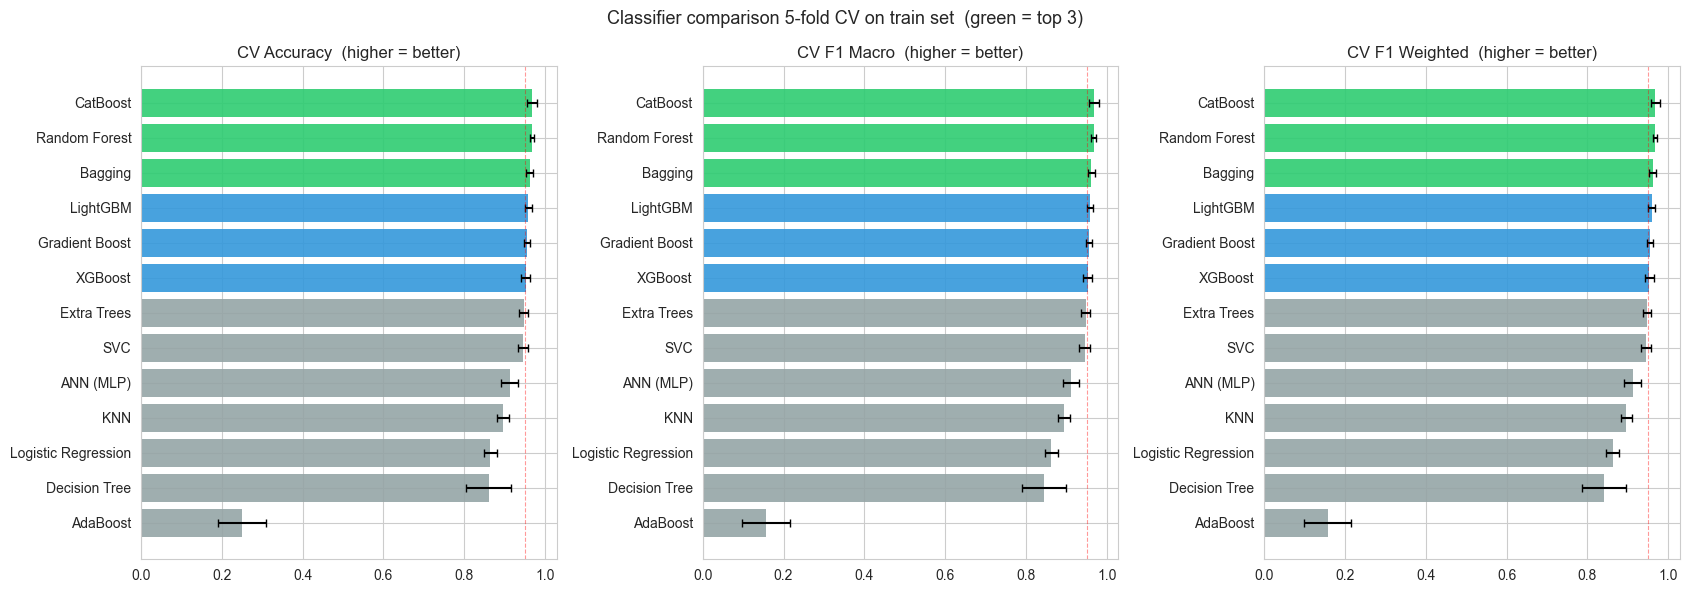

In [11]:
n = len(cv_df)
colors = ['#2ecc71' if i < 3 else '#3498db' if i < n//2 else '#95a5a6' for i in range(n)]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, metric, title in [
    (axes[0], 'CV_Acc',      'CV Accuracy  (higher = better)'),
    (axes[1], 'CV_F1_macro', 'CV F1 Macro  (higher = better)'),
    (axes[2], 'CV_F1_weighted', 'CV F1 Weighted  (higher = better)'),
]:
    ax.barh(cv_df['Model'][::-1], cv_df[metric][::-1],
            xerr=cv_df['CV_Acc_std'][::-1], color=colors[::-1],
            edgecolor='none', capsize=3, alpha=0.9)
    ax.set_title(title)
    ax.axvline(0.95, color='red', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle('Classifier comparison 5-fold CV on train set  (green = top 3)', fontsize=13)
plt.tight_layout()
plt.show()

## Bias-variance analysis

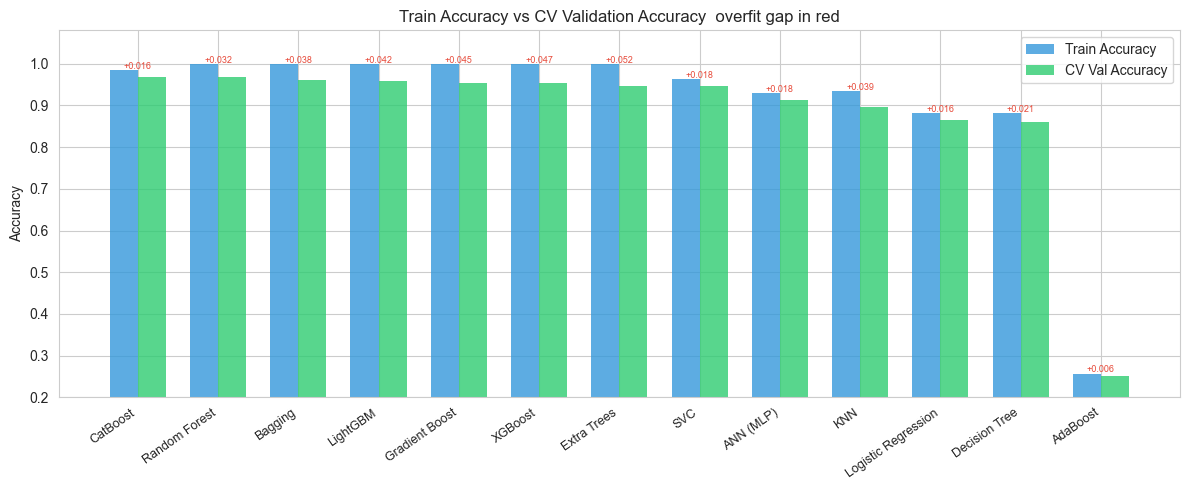

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(cv_df))
width = 0.35

ax.bar(x_pos - width/2, cv_df['Train_Acc'], width, label='Train Accuracy', color='#3498db', alpha=0.8, edgecolor='none')
ax.bar(x_pos + width/2, cv_df['CV_Acc'],    width, label='CV Val Accuracy', color='#2ecc71', alpha=0.8, edgecolor='none')

for i, row in cv_df.iterrows():
    ax.text(i, max(row['Train_Acc'], row['CV_Acc']) + 0.003,
            f"+{row['Overfit']:.3f}", ha='center', fontsize=6.5, color='#e74c3c')

ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Model'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.2, 1.08)
ax.set_title('Train Accuracy vs CV Validation Accuracy  overfit gap in red')
ax.legend()
plt.tight_layout()
plt.show()

## Final evaluation on held-out test set
Best model (CatBoost) retrained on the full train set, evaluated **once** on held-out test set.

In [13]:
BEST_NAME  = cv_df.iloc[0]['Model']
BEST_MODEL = CatBoostClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbose=0
)

BEST_MODEL.fit(X_train, y_train)
y_pred = BEST_MODEL.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average='macro')

print(f'Best model (by CV Accuracy): {BEST_NAME}')
print(f'\nFinal held-out test set performance (n={len(y_test)}):')
print(f'  Accuracy : {test_acc:.4f}')
print(f'  F1 macro : {test_f1:.4f}')
print(f'\nCV Accuracy (train set)  : {cv_df.iloc[0]["CV_Acc"]:.4f} +/- {cv_df.iloc[0]["CV_Acc_std"]:.4f}')
print(f'Test Accuracy (held-out) : {test_acc:.4f}')

Best model (by CV Accuracy): CatBoost

Final held-out test set performance (n=440):
  Accuracy : 0.9727
  F1 macro : 0.9729

CV Accuracy (train set)  : 0.9682 +/- 0.0118
Test Accuracy (held-out) : 0.9727


In [14]:
# Evaluate all models on test set
test_results = []
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    yp = model.predict(X_test)
    test_results.append({
        'Model'        : name,
        'CV_Acc'       : cv_df[cv_df['Model']==name]['CV_Acc'].values[0],
        'Test_Acc'     : round(accuracy_score(y_test, yp), 4),
        'Test_F1_macro': round(f1_score(y_test, yp, average='macro'), 4),
    })

test_df = pd.DataFrame(test_results).sort_values('CV_Acc', ascending=False).reset_index(drop=True)
print('CV Accuracy vs Test Accuracy for all models:')
print(test_df.to_string(index=False))

CV Accuracy vs Test Accuracy for all models:
              Model  CV_Acc  Test_Acc  Test_F1_macro
           CatBoost  0.9682    0.9727         0.9729
      Random Forest  0.9676    0.9705         0.9705
            Bagging  0.9619    0.9705         0.9704
           LightGBM  0.9585    0.9659         0.9658
     Gradient Boost  0.9545    0.9636         0.9635
            XGBoost  0.9528    0.9636         0.9637
        Extra Trees  0.9477    0.9523         0.9521
                SVC  0.9455    0.9500         0.9502
          ANN (MLP)  0.9125    0.9227         0.9229
                KNN  0.8966    0.8955         0.8946
Logistic Regression  0.8648    0.8818         0.8811
      Decision Tree  0.8608    0.7523         0.7077
           AdaBoost  0.2500    0.2818         0.2050


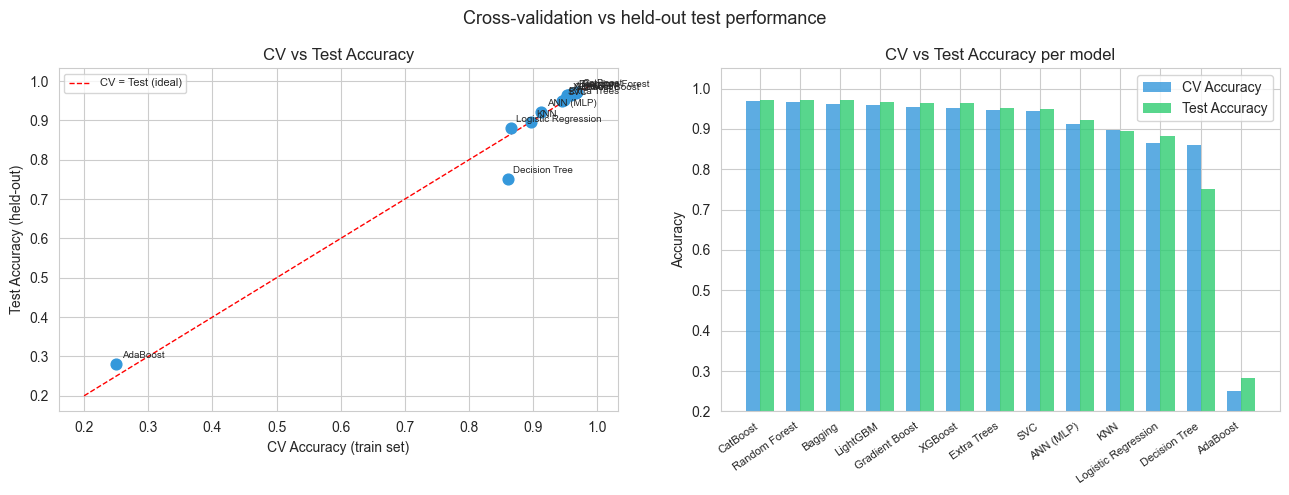

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(test_df['CV_Acc'], test_df['Test_Acc'], color='#3498db', s=60, zorder=3)
for _, row in test_df.iterrows():
    axes[0].annotate(row['Model'], (row['CV_Acc'], row['Test_Acc']),
                     fontsize=7, xytext=(4,4), textcoords='offset points')
lims = [min(test_df['CV_Acc'].min(), test_df['Test_Acc'].min()) - 0.05,
        max(test_df['CV_Acc'].max(), test_df['Test_Acc'].max()) + 0.02]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='CV = Test (ideal)')
axes[0].set_xlabel('CV Accuracy (train set)')
axes[0].set_ylabel('Test Accuracy (held-out)')
axes[0].set_title('CV vs Test Accuracy')
axes[0].legend(fontsize=8)

x_pos = np.arange(len(test_df))
width = 0.35
axes[1].bar(x_pos - width/2, test_df['CV_Acc'],  width, label='CV Accuracy',   color='#3498db', alpha=0.8, edgecolor='none')
axes[1].bar(x_pos + width/2, test_df['Test_Acc'], width, label='Test Accuracy', color='#2ecc71', alpha=0.8, edgecolor='none')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(test_df['Model'], rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.2, 1.05)
axes[1].set_title('CV vs Test Accuracy per model')
axes[1].legend()

plt.suptitle('Cross-validation vs held-out test performance', fontsize=13)
plt.tight_layout()
plt.show()

## Confusion matrix & classification report

In [16]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.90      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.95      0.90      0.92        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       0.83      0.95      0.88        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

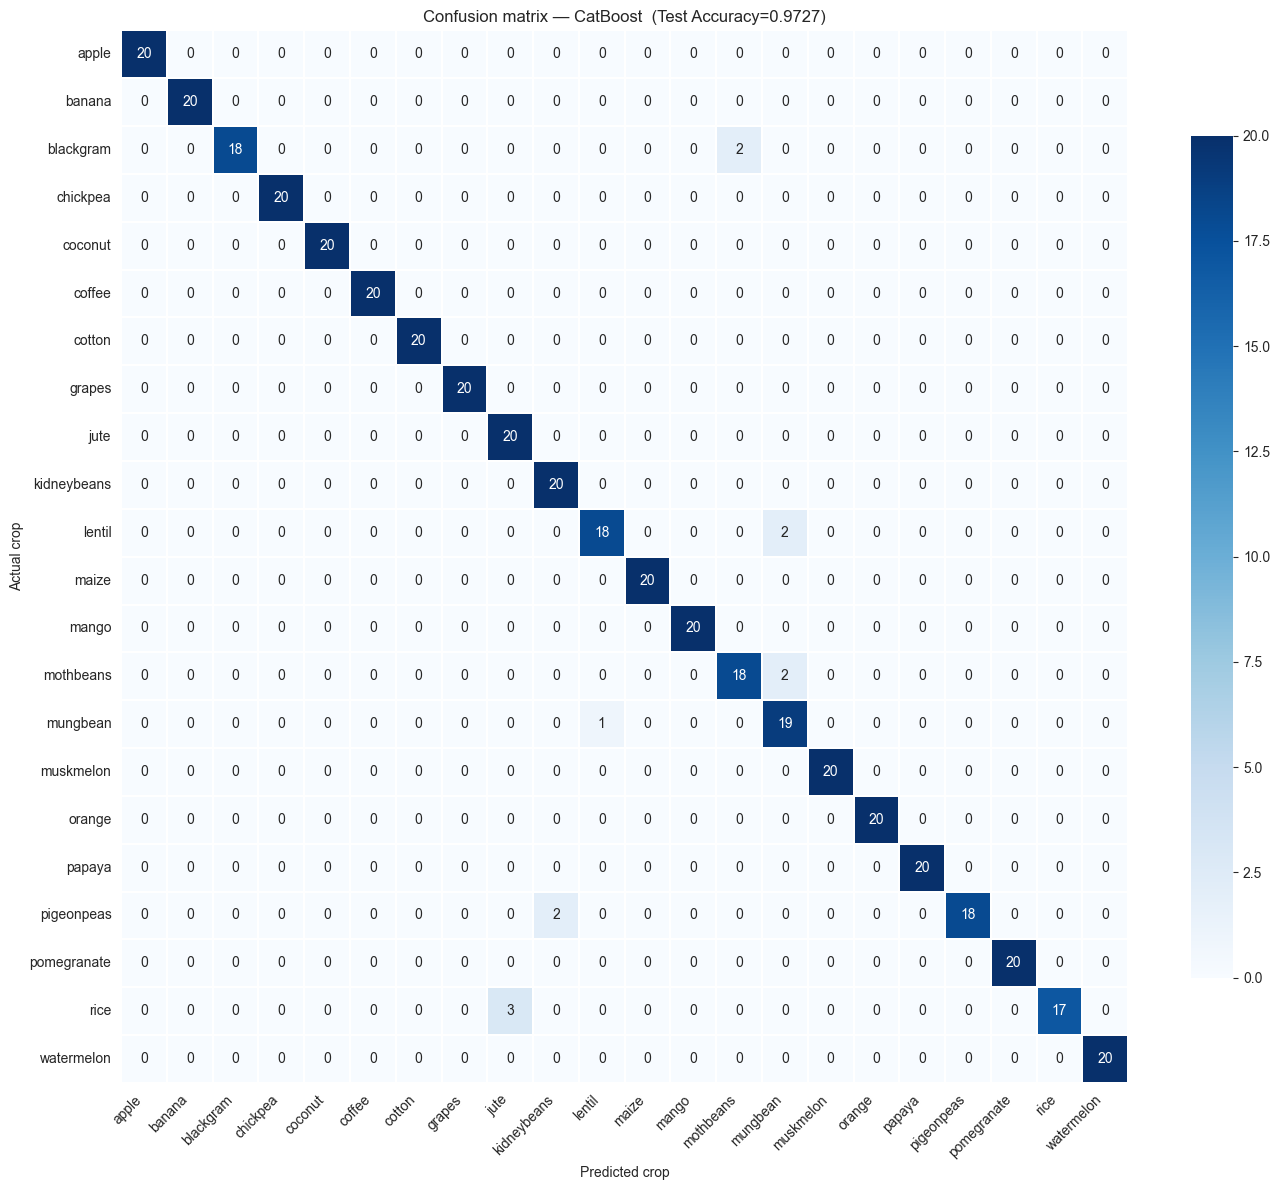

In [17]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.3, cbar_kws={'shrink':0.8})
ax.set_xlabel('Predicted crop')
ax.set_ylabel('Actual crop')
ax.set_title(f'Confusion matrix — {BEST_NAME}  (Test Accuracy={test_acc:.4f})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature importance

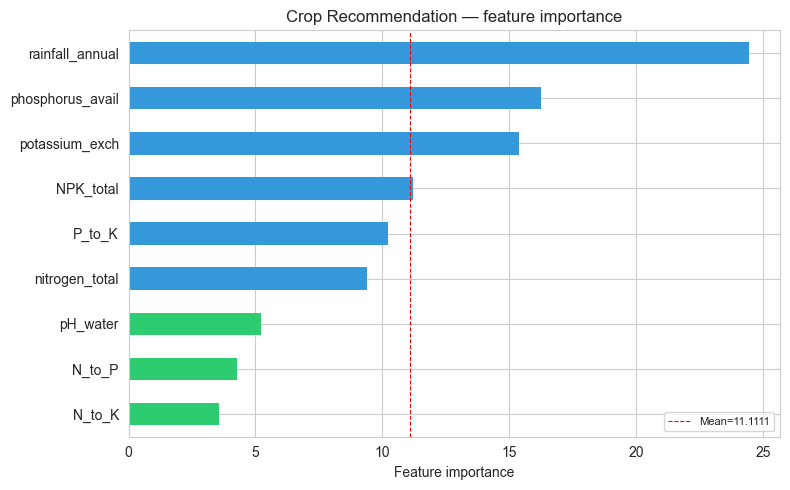

Numerical feature importances (ranked):
rainfall_annual     24.4545
phosphorus_avail    16.2476
potassium_exch      15.3848
NPK_total           11.2269
P_to_K              10.2299
nitrogen_total       9.3814
pH_water             5.2378
N_to_P               4.2721
N_to_K               3.5650


In [18]:
# Feature importance — numerical features only
NUMERICAL_FEATURES = [
    'nitrogen_total', 'phosphorus_avail', 'potassium_exch',
    'pH_water', 'rainfall_annual', 'NPK_total',
    'N_to_P', 'N_to_K', 'P_to_K'
]

# All features in classification are already numerical (no encoded categoricals)
num_idx = [FEATURES.index(f) for f in NUMERICAL_FEATURES]
importances = pd.Series(
    BEST_MODEL.feature_importances_[num_idx],
    index=NUMERICAL_FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#2ecc71' if i < 3 else '#3498db' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors_imp[::-1], edgecolor='none')
ax.invert_yaxis()
ax.set_xlabel('Feature importance')
ax.set_title(f'Crop Recommendation — feature importance')
ax.axvline(importances.mean(), color='red', linestyle='--',
           linewidth=0.8, label=f'Mean={importances.mean():.4f}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Numerical feature importances (ranked):')
print(importances.round(4).to_string())

## Apply to Sub-Saharan soil samples

In [19]:
# Retrain on full crop dataset
BEST_FULL = CatBoostClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, verbose=0
)
BEST_FULL.fit(X, y)

X_soil        = soil[FEATURES].values
X_soil_scaled = scaler.transform(X_soil)
proba         = BEST_FULL.predict_proba(X_soil_scaled)

# Top-3 crop predictions per sample
top3_idx = np.argsort(proba, axis=1)[:, -3:][:, ::-1]
soil_pred = soil.copy()
for rank in range(3):
    soil_pred[f'crop_rank{rank+1}']      = le.inverse_transform(top3_idx[:, rank])
    soil_pred[f'crop_rank{rank+1}_prob'] = proba[np.arange(len(proba)), top3_idx[:, rank]].round(4)

soil_pred['predicted_crop']        = soil_pred['crop_rank1']
soil_pred['prediction_confidence'] = soil_pred['crop_rank1_prob']

print('Top predicted crops across all 5,000 samples:')
print(soil_pred['predicted_crop'].value_counts())
print(f'\nMean prediction confidence: {soil_pred["prediction_confidence"].mean():.4f}')

Top predicted crops across all 5,000 samples:
predicted_crop
pigeonpeas    4239
orange         715
coconut         46
Name: count, dtype: int64

Mean prediction confidence: 0.8052


## Crop suitability per fertility zone

In [20]:
zone_order  = ['Low fertility','Medium-low fertility','Medium-high fertility','High fertility']
zone_colors_list = ['#e74c3c','#f39c12','#2ecc71','#3498db']
zone_colors = dict(zip(zone_order, zone_colors_list))

print('Top-3 crop suitability per fertility zone:\n')
for zone in zone_order:
    sub = soil_pred[soil_pred['zone_label'] == zone]
    print(f'  {zone} (n={len(sub)}):')
    for rank in range(1, 4):
        top = sub[f'crop_rank{rank}'].value_counts().head(3)
        print(f'    Rank {rank}: {dict(top)}')
    print()

Top-3 crop suitability per fertility zone:

  Low fertility (n=1336):
    Rank 1: {'pigeonpeas': np.int64(933), 'orange': np.int64(376), 'coconut': np.int64(27)}
    Rank 2: {'kidneybeans': np.int64(526), 'orange': np.int64(367), 'pigeonpeas': np.int64(191)}
    Rank 3: {'orange': np.int64(252), 'kidneybeans': np.int64(239), 'coconut': np.int64(234)}

  Medium-low fertility (n=1215):
    Rank 1: {'pigeonpeas': np.int64(870), 'orange': np.int64(326), 'coconut': np.int64(19)}
    Rank 2: {'kidneybeans': np.int64(546), 'orange': np.int64(261), 'coconut': np.int64(175)}
    Rank 3: {'orange': np.int64(232), 'coconut': np.int64(210), 'blackgram': np.int64(198)}

  Medium-high fertility (n=1139):
    Rank 1: {'pigeonpeas': np.int64(1134), 'orange': np.int64(5)}
    Rank 2: {'kidneybeans': np.int64(828), 'blackgram': np.int64(276), 'orange': np.int64(25)}
    Rank 3: {'blackgram': np.int64(398), 'kidneybeans': np.int64(296), 'rice': np.int64(293)}

  High fertility (n=1310):
    Rank 1: {'pig

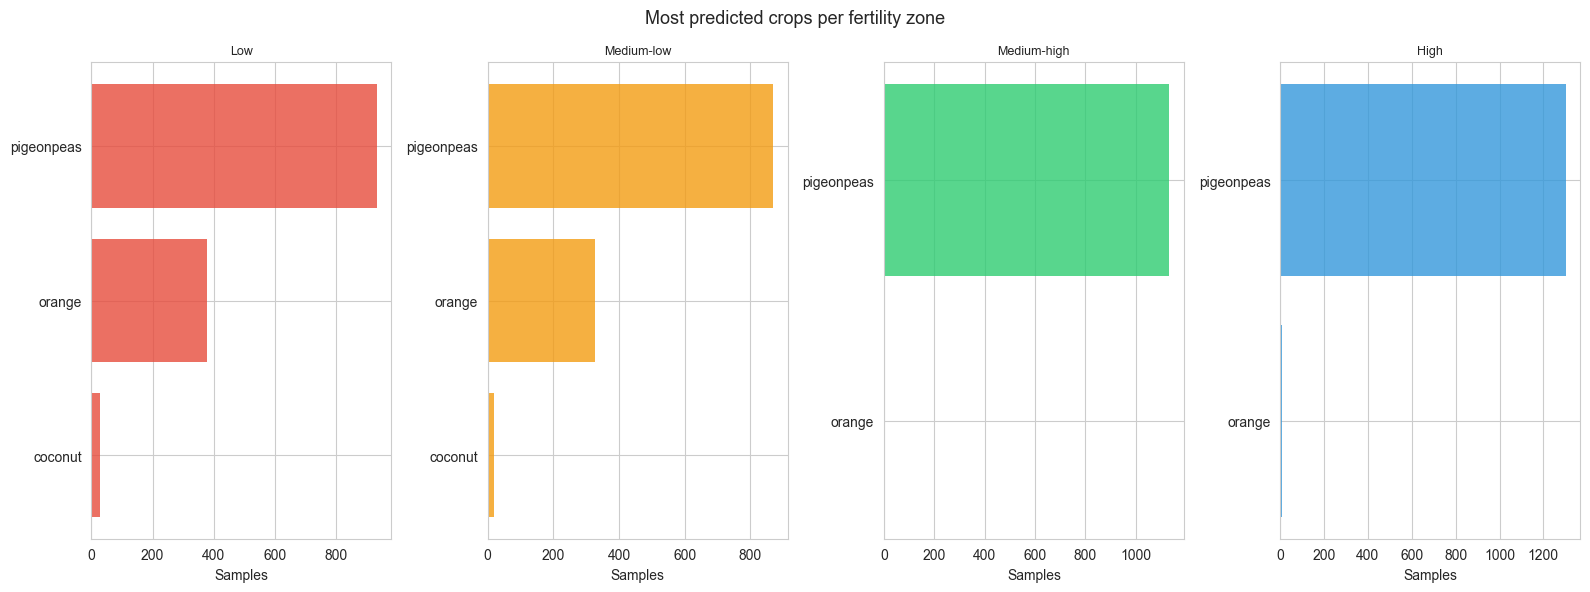

In [21]:
top_n = 6
zone_crop_counts = (
    soil_pred.groupby(['zone_label','predicted_crop'])
    .size().reset_index(name='count')
)

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=False)
for ax, zone, color in zip(axes, zone_order, zone_colors_list):
    sub = zone_crop_counts[zone_crop_counts['zone_label'] == zone]
    sub = sub.sort_values('count', ascending=False).head(top_n)
    ax.barh(sub['predicted_crop'][::-1], sub['count'][::-1], color=color, alpha=0.8, edgecolor='none')
    ax.set_title(zone.replace(' fertility',''), fontsize=9)
    ax.set_xlabel('Samples')

plt.suptitle('Most predicted crops per fertility zone', fontsize=13)
plt.tight_layout()
plt.show()

## Zone-crop suitability matrix

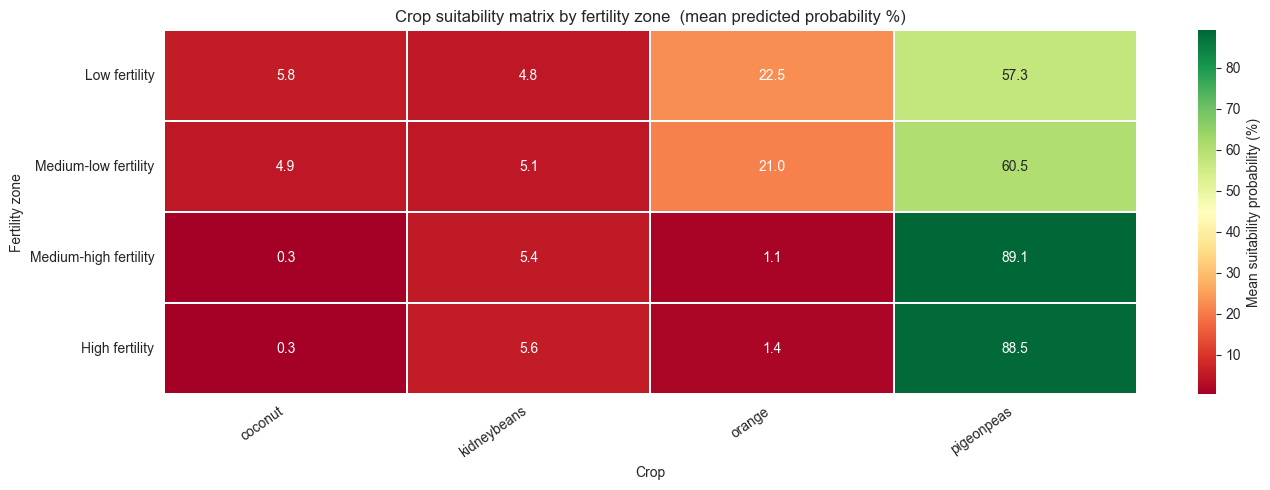

Most suitable crop per zone:
  Low fertility               : pigeonpeas  (57.3%)
  Medium-low fertility        : pigeonpeas  (60.5%)
  Medium-high fertility       : pigeonpeas  (89.1%)
  High fertility              : pigeonpeas  (88.5%)


In [22]:
crop_names = le.classes_.tolist()

zone_proba = {}
for zone in zone_order:
    mask = (soil_pred['zone_label'] == zone).values
    zone_proba[zone] = proba[mask].mean(axis=0)

# rows = zones, columns = crops
suitability_matrix = pd.DataFrame(zone_proba, index=crop_names).T
suitability_matrix = suitability_matrix.loc[zone_order]

# Keep only crops with mean prob > 2% in any zone
relevant_crops = suitability_matrix.columns[
    suitability_matrix.max(axis=0) > 0.02
].tolist()
suitability_matrix = suitability_matrix[relevant_crops]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    suitability_matrix * 100,
    annot=True, fmt='.1f', cmap='RdYlGn',
    ax=ax, linewidths=0.3,
    cbar_kws={'label': 'Mean suitability probability (%)'}
)
ax.set_title('Crop suitability matrix by fertility zone  (mean predicted probability %)')
ax.set_xlabel('Crop')
ax.set_ylabel('Fertility zone')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('Most suitable crop per zone:')
for zone in zone_order:
    best_crop = suitability_matrix.loc[zone].idxmax()
    best_prob = suitability_matrix.loc[zone].max()
    print(f'  {zone:<28}: {best_crop}  ({best_prob*100:.1f}%)')

## Save outputs

In [23]:
# Full comparison: CV + test metrics
full_comparison = cv_df.merge(test_df[['Model','Test_Acc','Test_F1_macro']], on='Model')
full_comparison.to_csv(f'{OUT_DIR}/classification_model_comparison.csv', index=False)
print('Saved classification_model_comparison.csv')

# Per-fold results
fold_df.to_csv(f'{OUT_DIR}/classification_fold_results.csv', index=False)
print('Saved classification_fold_results.csv')

# Crop predictions
pred_cols = ['sample_id','country','region','latitude','longitude',
             'zone','zone_label','fertility_score',
             'predicted_crop','prediction_confidence',
             'crop_rank1','crop_rank1_prob',
             'crop_rank2','crop_rank2_prob',
             'crop_rank3','crop_rank3_prob']
soil_pred[pred_cols].to_csv(f'{OUT_DIR}/crop_predictions.csv', index=False)
print('Saved crop_predictions.csv')

# Suitability matrix
suitability_matrix.round(4).to_csv(f'{OUT_DIR}/zone_crop_suitability_matrix.csv')
print('Saved zone_crop_suitability_matrix.csv')

print(f'\n[DONE] Track C complete.')
print(f'Best classifier  : {BEST_NAME}')
print(f'CV Accuracy      : {cv_df.iloc[0]["CV_Acc"]:.4f} +/- {cv_df.iloc[0]["CV_Acc_std"]:.4f}')
print(f'Test Accuracy    : {test_acc:.4f}')
print(f'Test F1 macro    : {test_f1:.4f}')

Saved classification_model_comparison.csv
Saved classification_fold_results.csv
Saved crop_predictions.csv
Saved zone_crop_suitability_matrix.csv

[DONE] Track C complete.
Best classifier  : CatBoost
CV Accuracy      : 0.9682 +/- 0.0118
Test Accuracy    : 0.9727
Test F1 macro    : 0.9729


**Import Model**

In [24]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Re-fit a classification feature scaler matching your training scope dimensional inputs
classification_scaler = StandardScaler()
classification_scaler.fit(X_train)

# 2. Bundle the scaling layer with your BEST_MODEL classification ensemble
classification_pipeline = Pipeline([
    ('scaler', classification_scaler),
    ('classifier', BEST_MODEL)
])

# 3. Export the predictive model pipeline
crop_pipeline_filename = 'crop_classification_pipeline.joblib'
joblib.dump(classification_pipeline, crop_pipeline_filename)

# 4. Export the LabelEncoder fitted on crop name strings (variable: le)
joblib.dump(le, 'crop_label_encoder.joblib')

print(" Successfully exported Crop Classification Pipeline and Label Encoder.")

 Successfully exported Crop Classification Pipeline and Label Encoder.
